<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-ML/blob/main/DL_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d47f6c7d9dbb53be3502d5a31daad4cfd18ce89f6e95a325764827938409f7c6
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

In [5]:
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df  = pd.read_csv(url)

print("HEART DISEASE DATASET INFO")
print(f"Columns         : {list(df.columns)}")

HEART DISEASE DATASET INFO
Columns         : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
X = df.drop('target', axis=1).values
y = df['target'].values

feature_names = list(df.drop('target', axis=1).columns)

print(f"\nFeatures        : {feature_names}")
print(f"Total Features  : {len(feature_names)}")
print(f"Total Samples   : {X.shape[0]}")


Features        : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Total Features  : 13
Total Samples   : 303


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain samples   : {X_train.shape[0]}")
print(f"Test samples    : {X_test.shape[0]}")


Train samples   : 242
Test samples    : 61


In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu',
                          input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
print("\nTraining MLP Model...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Training MLP Model...
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9430 - loss: 0.1745 - val_accuracy: 0.8163 - val_loss: 0.5833
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9326 - loss: 0.1922 - val_accuracy: 0.8163 - val_loss: 0.5931
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9637 - loss: 0.1565 - val_accuracy: 0.8163 - val_loss: 0.5932
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9534 - loss: 0.1510 - val_accuracy: 0.8163 - val_loss: 0.5885
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9275 - loss: 0.1652 - val_accuracy: 0.8163 - val_loss: 0.5880
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9378 - loss: 0.1701 - val_accuracy: 0.8163 - val_loss: 0.5878
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9482 - loss: 0.1515 - val_accuracy: 0.8163 - val_loss: 0.5917
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9378 - loss: 0.1756 - val_accur


Evaluating MLP Model on Test Data...
Test Loss: 0.9736
Test Accuracy: 0.8361


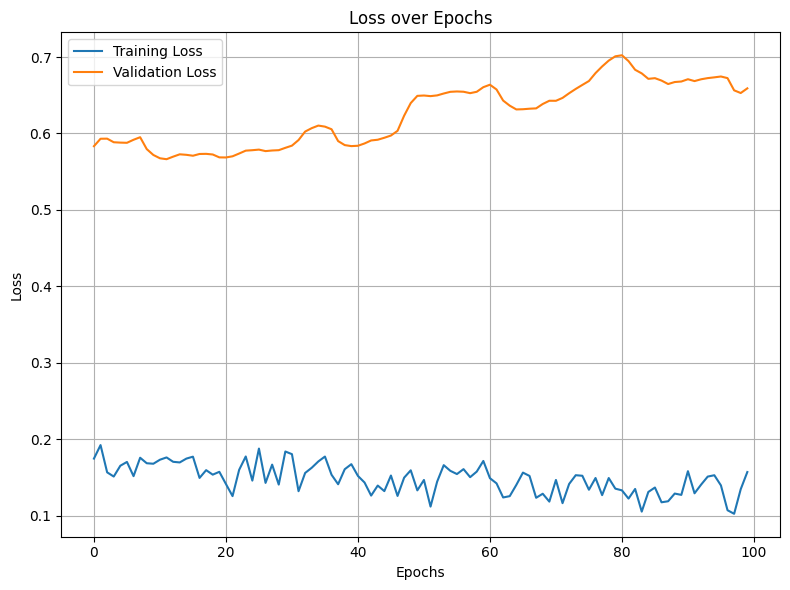

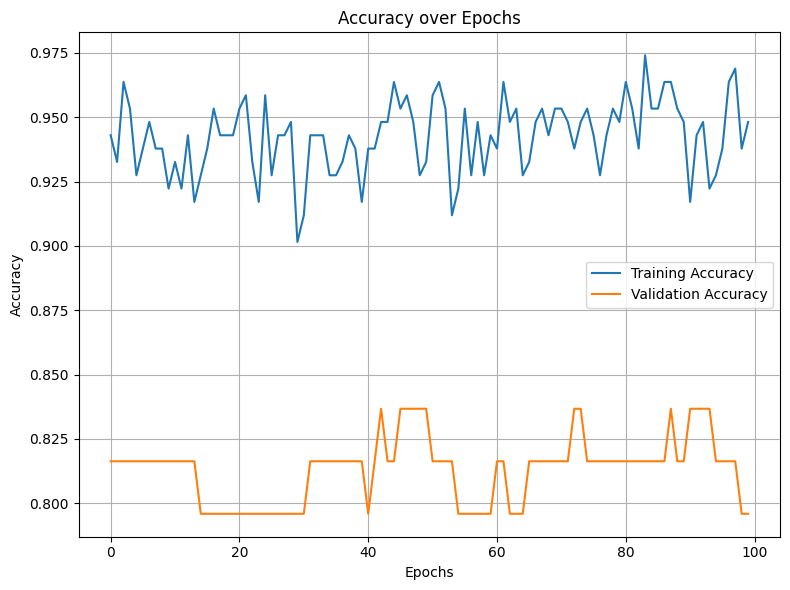

In [21]:
print("\nEvaluating MLP Model on Test Data...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

test_loss = loss
test_accuracy = accuracy


plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# LIME needs predict_proba format → wrap model output
def predict_fn(X):
    prob_positive = model.predict(X, verbose=0).flatten()
    prob_negative = 1 - prob_positive
    return np.column_stack([prob_negative, prob_positive])

# Create LIME Tabular Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=['No Disease', 'Heart Disease'],
    mode='classification',
    random_state=42
)

print("\nLIME Explainer Created Successfully!")


LIME Explainer Created Successfully!


In [24]:
# Pick sample index 0 from test set
# Calculate predictions for the entire test set first
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

sample_idx    = 0
sample        = X_test[sample_idx]
true_label    = y_test[sample_idx]
pred_prob     = y_pred_prob[sample_idx]
pred_label    = y_pred[sample_idx]

print(f"\nSelected Test Sample Index : {sample_idx}")
print(f"True Label                 : {'Heart Disease' if true_label == 1 else 'No Disease'}")
print(f"Predicted Label            : {'Heart Disease' if pred_label == 1 else 'No Disease'}")
print(f"Prediction Probability     : {pred_prob:.4f}")

# Generate LIME explanation
explanation = explainer.explain_instance(
    data_row=sample,
    predict_fn=predict_fn,
    num_features=len(feature_names)   # Show all features
)


Selected Test Sample Index : 0
True Label                 : No Disease
Predicted Label            : No Disease
Prediction Probability     : 0.0157


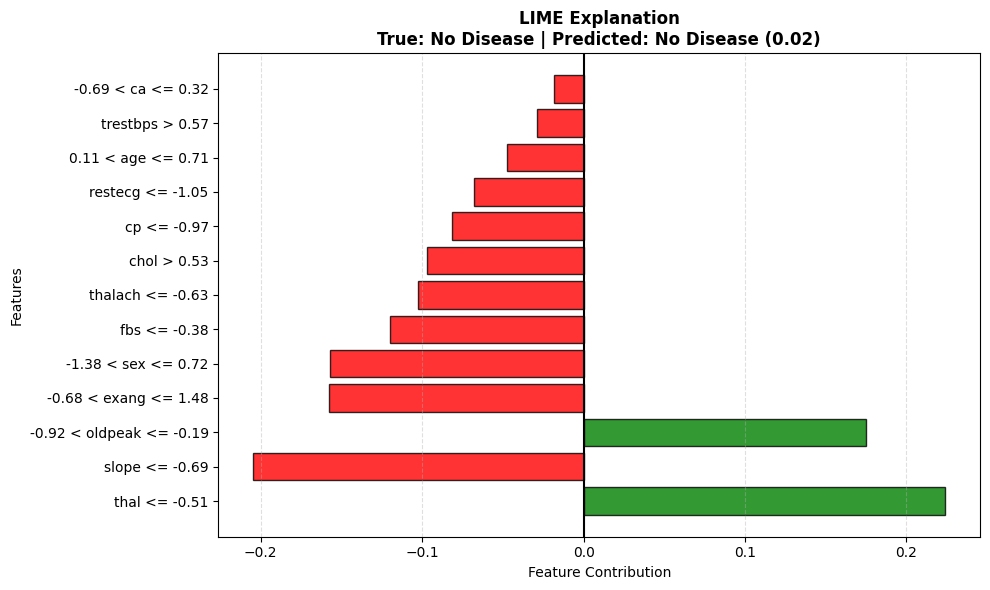

In [27]:
# Get feature contributions
exp_list = explanation.as_list()

# Separate positive and negative contributions
feat_labels = [x[0] for x in exp_list]
feat_values = [x[1] for x in exp_list]
colors      = ['green' if v > 0 else 'red' for v in feat_values]

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_labels, feat_values,
                color=colors, edgecolor='black', alpha=0.8)
plt.axvline(x=0, color='black', linewidth=1.5)
plt.title(
    f'LIME Explanation\n'
    f'True: {"Heart Disease" if true_label==1 else "No Disease"} | '
    f'Predicted: {"Heart Disease" if pred_label==1 else "No Disease"} '
    f'({pred_prob:.2f})',
    fontweight='bold', fontsize=12
)
plt.xlabel('Feature Contribution')
plt.ylabel('Features')
plt.grid(True, linestyle='--', alpha=0.4, axis='x')
plt.tight_layout()
plt.show()


Calculating Average LIME Feature Importance...


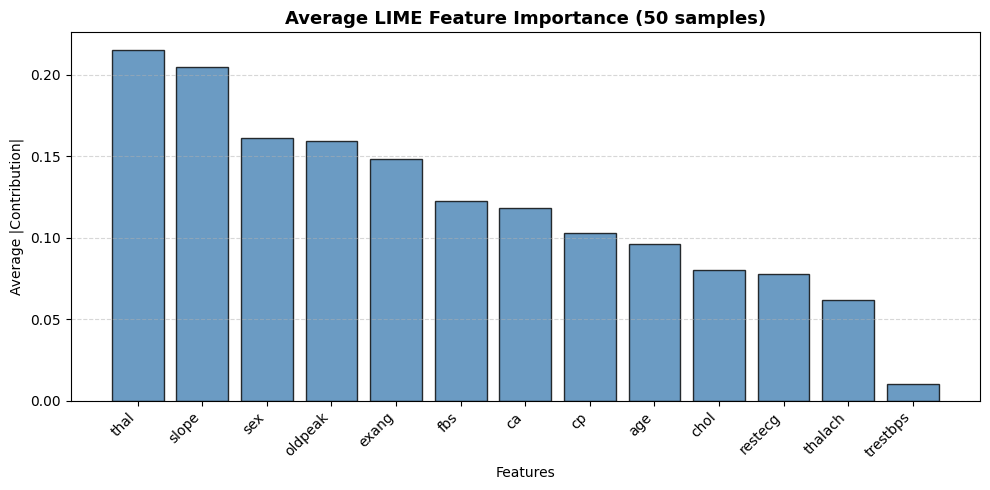

In [28]:
# Average absolute LIME contributions across multiple samples
print("\nCalculating Average LIME Feature Importance...")

n_samples       = 50
lime_importance = np.zeros(len(feature_names))

for i in range(n_samples):
    exp_i    = explainer.explain_instance(
                    data_row=X_test[i],
                    predict_fn=predict_fn,
                    num_features=len(feature_names)
               )
    exp_dict = dict(exp_i.as_list())
    for j, fname in enumerate(feature_names):
        # Match feature name (LIME adds conditions like "> 0.5")
        for key in exp_dict:
            if fname in key:
                lime_importance[j] += abs(exp_dict[key])
                break

lime_importance /= n_samples

# Sort
indices   = np.argsort(lime_importance)[::-1]
sorted_fn = [feature_names[i] for i in indices]
sorted_im = lime_importance[indices]

plt.figure(figsize=(10, 5))
plt.bar(sorted_fn, sorted_im,
        color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Average LIME Feature Importance (50 samples)',
          fontweight='bold', fontsize=13)
plt.xlabel('Features')
plt.ylabel('Average |Contribution|')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()